# CS313 Deep Learning for AI - Final Project
**Time-series Data and Application to Stock Markets**

| | |
|---|---|
| **Student ID** | `230163` |
| **Name** | `Huynh Nhat Huyen` |
| **GitHub** | `<your-repo-link>` |

---
### Table of Contents
- [0. Setup & Imports](#0)
- [Task 1 — Nasdaq Prediction](#task1)
- [Task 2 — Vietnam Prediction](#task2)
- [Task 3 — Trading Signals](#task3)
- [Task 4 — Portfolio Optimization](#task4)
- [Task 5 — Deployment](#task5)

---
## 0. Setup & Imports <a id='0'></a>

In [16]:
#Install necessary packages

!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [17]:
# Import libraries
import os, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from scipy.optimize import minimize


# check GPU
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


In [ ]:
# set paths
NASDAQ_DIR   = r"c:\Users\Administrator\230163-DL4AI-project\data_nasdaq_csv\csv"
VN_PRICE_DIR = r"c:\Users\Administrator\230163-DL4AI-project\data-vn-20230228\stock-historical-data"
VN_DIV_DIR   = r"c:\Users\Administrator\230163-DL4AI-project\data-vn-20230228\dividend-history"
VN_FIN_DIR   = r"c:\Users\Administrator\230163-DL4AI-project\data-vn-20230228\financial-ratio"
VN_COMPANIES = r"c:\Users\Administrator\230163-DL4AI-project\data-vn-20230228\companies.csv"
VN_OVERVIEW  = r"c:\Users\Administrator\230163-DL4AI-project\data-vn-20230228\ticker-overview.csv"

MIN_DAYS    = 200           # keep tickers with >= 200 trading days since cutoff
WINDOW      = 45            # 45-day lookback — more context, still fast
DATE_CUTOFF = '2018-01-01'  # use data from 2018 onwards — clean price scales, no old splits

print(os.listdir(NASDAQ_DIR)[:5])
print(os.listdir(VN_PRICE_DIR)[:5])


In [ ]:
# ══════════════════════════════════════
# SHARED UTILITIES
# ══════════════════════════════════════

def clean_ohlcv(df, price_cols=('Open', 'High', 'Low', 'Close')):
    df = df.copy()
    for col in price_cols:
        if col in df.columns:
            df = df[df[col] > 0]
    if 'Close' in df.columns and len(df) > 30:
        lr      = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        q1, q3  = lr.quantile(0.01), lr.quantile(0.99)
        fence   = 3 * (q3 - q1)
        bad_idx = lr[(lr < q1 - fence) | (lr > q3 + fence)].index
        if len(bad_idx):
            df = df.drop(index=bad_idx, errors='ignore')
    return df.reset_index(drop=True)


def add_indicators(df):
    df   = df.copy()
    c    = df['Close']
    df['sma5']   = c.rolling(5).mean()
    df['sma20']  = c.rolling(20).mean()
    d    = c.diff()
    gain = d.clip(lower=0).rolling(14).mean()
    loss = (-d.clip(upper=0)).rolling(14).mean()
    df['rsi14']  = 100 - 100 / (1 + gain / loss)
    e12  = c.ewm(span=12, adjust=False).mean()
    e26  = c.ewm(span=26, adjust=False).mean()
    df['macd']   = e12 - e26
    df['macd_s'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_h'] = df['macd'] - df['macd_s']
    std20 = c.rolling(20).std()
    df['bb_u']   = df['sma20'] + 2 * std20
    df['bb_l']   = df['sma20'] - 2 * std20
    df['bb_w']   = df['bb_u'] - df['bb_l']
    return df.dropna()


def make_sequences(feat_scaled, targets, window, horizon=1):
    X, y = [], []
    for i in range(window, len(feat_scaled) - horizon + 1):
        X.append(feat_scaled[i - window: i])
        if horizon == 1:
            y.append(targets[i])
        else:
            y.append(targets[i: i + horizon])
    return np.array(X), np.array(y)


def make_seq_ahead(feat_scaled, targets, window, d):
    # Single-output target exactly d steps ahead — avoids Dense(k) MSE collapse.
    X, y = [], []
    for i in range(window, len(feat_scaled) - d + 1):
        X.append(feat_scaled[i - window: i])
        y.append(targets[i + d - 1])
    return np.array(X), np.array(y)


def chrono_split(X, y, val=0.15, test=0.15):
    n  = len(X)
    t2 = int(n * (1 - test))
    t1 = int(t2 * (1 - val / (1 - test)))
    return X[:t1], y[:t1], X[t1:t2], y[t1:t2], X[t2:], y[t2:]


def eval_regression(y_true, y_pred, tag=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'{tag}  MAE={mae:.4f}  RMSE={rmse:.4f}')
    return mae, rmse


def plot_pred(y_true_lr, y_pred_lr, title='', close_arr=None, t_start=0):
    """
    Top panel  : actual vs predicted log-returns.
    Bottom panel: actual close prices and one-step predicted prices.
                  One-step prediction: pred_p[i] = actual_p[i-1] * exp(pred_lr[i])
                  This anchors each prediction to yesterday's real price, so both
                  lines stay in the same price range (no compounding drift).
    """
    show_price = (close_arr is not None) and (t_start > 0)
    fig, axes = plt.subplots(1 if not show_price else 2, 1,
                             figsize=(12, 4 if not show_price else 8))
    if not show_price:
        axes = [axes]
    axes[0].plot(y_true_lr, lw=1.1, label='Actual log-return')
    axes[0].plot(y_pred_lr, lw=1.1, ls='--', alpha=0.85, label='Predicted log-return')
    axes[0].axhline(0, color='gray', lw=0.6, ls=':')
    axes[0].set_title(title + ' — log-return predictions')
    axes[0].legend()
    if show_price:
        n     = len(y_true_lr)
        act_p = close_arr[t_start: t_start + n].astype(float)
        # One-step: each predicted price anchors to the previous actual price
        prev_p = close_arr[t_start - 1: t_start + n - 1].astype(float)
        pred_p = prev_p * np.exp(y_pred_lr.astype(float))
        axes[1].plot(act_p,  lw=1.2, label='Actual price')
        axes[1].plot(pred_p, lw=1.2, ls='--', alpha=0.85, label='Predicted price (1-step)')
        axes[1].set_title('Close prices — actual vs one-step predicted')
        axes[1].legend()
    plt.tight_layout(); plt.show()


def build_lstm(input_shape, output_units=1, classify=False):
    """2-layer LSTM with BatchNorm — good balance of speed and capacity."""
    inp = keras.Input(shape=input_shape)
    x   = layers.LSTM(64, return_sequences=True)(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.2)(x)
    x   = layers.LSTM(32)(x)
    x   = layers.Dropout(0.1)(x)
    if classify:
        out  = layers.Dense(output_units, activation='softmax')(x)
        loss = 'sparse_categorical_crossentropy'
        met  = ['accuracy']
    else:
        out  = layers.Dense(output_units)(x)
        loss = 'mse'
        met  = ['mae']
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss=loss, metrics=met)
    return m


def _get_close(d, prefer_adjusted=True):
    """Return the close price array, preferring Adjusted Close when available."""
    if prefer_adjusted and 'Adjusted Close' in d.columns:
        return d['Adjusted Close'].values.astype(float)
    return d['Close'].values.astype(float)


def train_one(df_co, features, window=WINDOW, horizon=1, epochs=30, verbose=0,
              use_indicators=True):
    d = df_co.sort_values('Date').copy()
    d = clean_ohlcv(d)
    if use_indicators:
        d = add_indicators(d)
    d = d[features].dropna().reset_index(drop=True)
    close = _get_close(d)
    lr    = np.concatenate([[0.0], np.log(close[1:] / (close[:-1] + 1e-9))])
    sc    = MinMaxScaler()
    s     = sc.fit_transform(d)
    X, y  = make_sequences(s, lr, window, horizon=1)
    Xtr, ytr, Xval, yval, Xte, yte = chrono_split(X, y)
    t_start = len(Xtr) + len(Xval) + window
    last_close = float(close[t_start]) if t_start < len(close) else float(close[-1])
    es  = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    rlr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                            patience=3, min_lr=1e-5)
    m   = build_lstm((window, len(features)), output_units=1)
    m.fit(Xtr, ytr, validation_data=(Xval, yval),
          epochs=epochs, batch_size=32, callbacks=[es, rlr], verbose=verbose)
    ypred = m.predict(Xte, verbose=0).flatten()
    return m, sc, yte, ypred, last_close, close, t_start


def _prep_ticker(df_co, features, use_indicators=True):
    d = df_co.sort_values('Date').copy()
    d = clean_ohlcv(d)
    if use_indicators:
        d = add_indicators(d)
    d = d[features].dropna().reset_index(drop=True)
    close = _get_close(d)
    lr    = np.concatenate([[0.0], np.log(close[1:] / (close[:-1] + 1e-9))])
    sc    = MinMaxScaler()
    s     = sc.fit_transform(d)
    return close, lr, s


print('Utilities ready.')


---
## Task 1 — Nasdaq Stock Price Prediction <a id='task1'></a>
> **15%** | 1.1 multi-feature · 1.2 k-th day · 1.3 k consecutive days

### 1.0 Load & Filter Data

In [ ]:
def load_nasdaq(d, min_days=MIN_DAYS):
    frames = []
    for f in os.listdir(d):
        if not f.endswith('.csv'):
            continue
        df = pd.read_csv(os.path.join(d, f), parse_dates=['Date'], on_bad_lines='skip')
        df['Ticker'] = f.replace('.csv', '')
        frames.append(df)
    all_df = pd.concat(frames, ignore_index=True)
    all_df['Date'] = pd.to_datetime(all_df['Date'], errors='coerce')
    all_df = all_df.dropna(subset=['Date'])
    all_df = all_df[all_df['Date'] >= pd.Timestamp(DATE_CUTOFF)]
    keep   = all_df.groupby('Ticker')['Date'].count()
    all_df = all_df[all_df['Ticker'].isin(keep[keep >= min_days].index)]
    print(f'Nasdaq: {keep[keep >= min_days].shape[0]} companies kept (since {DATE_CUTOFF})')
    return all_df.sort_values(['Ticker', 'Date'])

nasdaq = load_nasdaq(NASDAQ_DIR)
nasdaq.head()


Rows: 1246 raw  →  1227 after cleaning


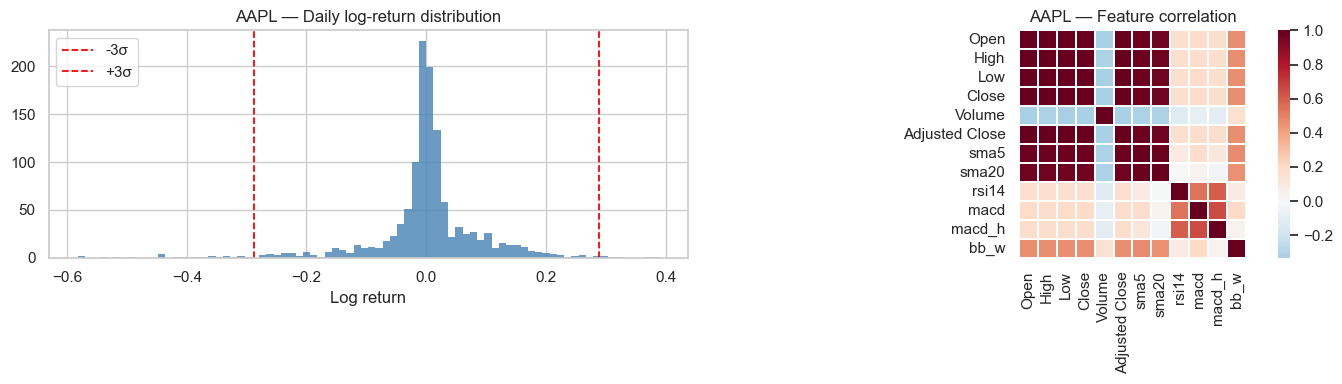

,Open,High,Low,Close,Volume,Adjusted Close,sma5,sma20,rsi14,macd,macd_h,bb_w
1241,145.759995,148.449997,145.050003,145.860001,77588800.0,145.416443,155.928000,150.677998,47.693671,0.094964,0.083197,37.244662
1242,169.820007,172.169998,169.399994,172.100006,68039400.0,171.814987,160.742001,152.039499,60.081311,1.710947,1.359344,41.400271
1243,159.589996,164.259995,159.300003,163.429993,104956000.0,163.159332,158.322000,151.786498,55.194110,2.265907,1.531444,39.928337
1244,139.130005,140.360001,138.160004,138.339996,70433700.0,138.110886,152.457999,151.754498,45.591342,0.673402,-0.048849,40.104910
1245,142.699997,143.000000,141.070007,142.320007,21904917.0,142.320007,152.410001,151.385499,48.072106,-0.264468,-0.789375,40.957436


In [23]:
TICKER_NQ = 'AAPL'
NQ_FEATS  = ['Open', 'High', 'Low', 'Close', 'Volume', 'Adjusted Close',
             'sma5', 'sma20', 'rsi14', 'macd', 'macd_h', 'bb_w']

# ── EDA: clean + add indicators, then visualise outliers ──────────────────
sample_raw = nasdaq[nasdaq['Ticker'] == TICKER_NQ].sort_values('Date').copy()
n_before   = len(sample_raw)
sample_raw = clean_ohlcv(sample_raw)
sample     = add_indicators(sample_raw)
print(f'Rows: {n_before} raw  →  {len(sample)} after cleaning')

log_ret = np.log(sample['Close'] / sample['Close'].shift(1)).dropna()
mu_lr, sd_lr = log_ret.mean(), log_ret.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: log-return histogram with ±3σ fence
axes[0].hist(log_ret, bins=80, color='steelblue', alpha=0.8, edgecolor='none')
for s, lbl in [(-3, '-3σ'), (3, '+3σ')]:
    axes[0].axvline(mu_lr + s * sd_lr, color='red', ls='--', lw=1.3, label=lbl)
axes[0].set_title(f'{TICKER_NQ} — Daily log-return distribution')
axes[0].set_xlabel('Log return'); axes[0].legend()

# Right: feature correlation heatmap
corr = sample[NQ_FEATS].corr()
sns.heatmap(corr, ax=axes[1], cmap='RdBu_r', center=0,
            annot=False, linewidths=0.3, square=True)
axes[1].set_title(f'{TICKER_NQ} — Feature correlation')

plt.tight_layout(); plt.show()
sample[NQ_FEATS].tail()

### 1.1 Multi-feature Extension

In [ ]:
m11, sc11, yte11, ypred11, lc11, close11, ts11 = train_one(
    nasdaq[nasdaq['Ticker'] == TICKER_NQ], NQ_FEATS, epochs=30, verbose=1)
eval_regression(yte11, ypred11, '[Task 1.1]')
plot_pred(yte11, ypred11, 'Task 1.1 -- AAPL next-day',
          close_arr=close11, t_start=ts11)


### 1.2 k-th Day Forecast

In [ ]:
for k in [3, 7]:
    close12, lr12, s12 = _prep_ticker(
        nasdaq[nasdaq['Ticker'] == TICKER_NQ], NQ_FEATS)
    X, y = make_seq_ahead(s12, lr12, WINDOW, d=k)
    Xtr, ytr, Xval, yval, Xte, yte_k = chrono_split(X, y)
    X1, _ = make_seq_ahead(s12, lr12, WINDOW, 1)
    Xtr1, _, Xval1, _, _, _ = chrono_split(X1, np.zeros(len(X1)))
    t_start12 = len(Xtr1) + len(Xval1) + WINDOW
    es  = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    rlr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                            patience=3, min_lr=1e-5)
    m   = build_lstm((WINDOW, len(NQ_FEATS)), output_units=1)
    m.fit(Xtr, ytr, validation_data=(Xval, yval),
          epochs=30, batch_size=32, callbacks=[es, rlr], verbose=0)
    ypred_k = m.predict(Xte, verbose=0).flatten()
    eval_regression(yte_k, ypred_k, f'[Task 1.2 k={k}]')
    plot_pred(yte_k, ypred_k, f'Task 1.2 -- AAPL {k}-th day',
              close_arr=close12, t_start=t_start12)


### 1.3 k Consecutive Days Forecast

In [ ]:
K = 7
close13, lr13, s13 = _prep_ticker(
    nasdaq[nasdaq['Ticker'] == TICKER_NQ], NQ_FEATS)

yte_days, ypred_days = [], []
for d in range(1, K + 1):
    X, y = make_seq_ahead(s13, lr13, WINDOW, d)
    Xtr, ytr, Xval, yval, Xte, yte_d = chrono_split(X, y)
    es  = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    rlr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                            patience=3, min_lr=1e-5)
    md  = build_lstm((WINDOW, len(NQ_FEATS)), output_units=1)
    md.fit(Xtr, ytr, validation_data=(Xval, yval),
           epochs=30, batch_size=32, callbacks=[es, rlr], verbose=0)
    yp_d = md.predict(Xte, verbose=0).flatten()
    yte_days.append(yte_d)
    ypred_days.append(yp_d)
    eval_regression(yte_d, yp_d, f'[Task 1.3 day+{d}]')

# Aligned 7-day chart anchored at test-set boundary of model d=1
X1, _ = make_seq_ahead(s13, lr13, WINDOW, 1)
Xtr1, _, Xval1, _, _, _ = chrono_split(X1, np.zeros(len(X1)))
t_start = len(Xtr1) + len(Xval1) + WINDOW   # index into close13

lc13 = float(close13[t_start - 1])

# Actual: read directly from close13 — no accumulation error
act_p = [float(close13[t_start + d - 1]) for d in range(1, K + 1)]

# Predicted: cumulative predicted log-returns applied to anchor
pred_lr_cum = np.cumsum([float(ypred_days[d][0]) for d in range(K)])
pred_p = [lc13 * float(np.exp(c)) for c in pred_lr_cum]

plt.figure(figsize=(8, 4))
plt.plot(range(1, K + 1), act_p,  'o-',  label='Actual')
plt.plot(range(1, K + 1), pred_p, 's--', label='Predicted')
plt.xlabel('Day ahead'); plt.ylabel('Close price ($)')
plt.title('Task 1.3 — 7-day consecutive forecast (separate model per horizon)')
plt.legend(); plt.tight_layout(); plt.show()


### 1.4 Time-series Cross-Validation

In [27]:
tscv  = TimeSeriesSplit(n_splits=5)
sc_cv = MinMaxScaler()

_nq_cv = nasdaq[nasdaq['Ticker'] == TICKER_NQ].sort_values('Date').copy()
_nq_cv = clean_ohlcv(_nq_cv)
_nq_cv = add_indicators(_nq_cv)
_nq_cv = _nq_cv[NQ_FEATS].dropna().reset_index(drop=True)

close_cv  = _nq_cv.iloc[:, 3].values
lr_cv     = np.concatenate([[0.0], np.log(close_cv[1:] / (close_cv[:-1] + 1e-9))])
s_cv      = sc_cv.fit_transform(_nq_cv)
Xa, ya    = make_sequences(s_cv, lr_cv, WINDOW)

maes = []
for fold, (tr, val) in enumerate(tscv.split(Xa)):
    m = build_lstm((WINDOW, len(NQ_FEATS)))
    m.fit(Xa[tr], ya[tr], epochs=20, batch_size=32, verbose=0)
    p = m.predict(Xa[val], verbose=0).flatten()
    mae, _ = eval_regression(ya[val], p, f'CV fold {fold+1}')
    maes.append(mae)
print(f'Mean CV MAE: {np.mean(maes):.4f} ± {np.std(maes):.4f}  (~{np.mean(maes)*100:.2f}%)')

CV fold 1  MAE=0.0604  RMSE=0.1080
CV fold 2  MAE=0.0806  RMSE=0.1295
CV fold 3  MAE=0.0814  RMSE=0.1031
CV fold 4  MAE=0.0449  RMSE=0.0657
CV fold 5  MAE=0.0467  RMSE=0.0682
Mean CV MAE: 0.0628 ± 0.0158  (~6.28%)


---
## Task 2 — Vietnam Stock Price Prediction <a id='task2'></a>
> **15%** | Same subtask structure applied to Vietnam market data

### 2.0 Load & Filter Data

In [ ]:
def load_vietnam(d, min_days=MIN_DAYS):
    frames = []
    for f in os.listdir(d):
        if not f.endswith('.csv'):
            continue
        ticker = f.split('-')[0]
        df = pd.read_csv(os.path.join(d, f), parse_dates=['TradingDate'])
        df = df.rename(columns={'TradingDate': 'Date'})
        df['Ticker'] = ticker
        frames.append(df)
    all_df = pd.concat(frames, ignore_index=True)
    all_df['Date'] = pd.to_datetime(all_df['Date'], errors='coerce')
    all_df = all_df.dropna(subset=['Date'])
    all_df = all_df[all_df['Date'] >= pd.Timestamp(DATE_CUTOFF)]
    keep   = all_df.groupby('Ticker')['Date'].count()
    all_df = all_df[all_df['Ticker'].isin(keep[keep >= min_days].index)]
    print(f'Vietnam: {keep[keep >= min_days].shape[0]} companies kept (since {DATE_CUTOFF})')
    return all_df.sort_values(['Ticker', 'Date'])

vn = load_vietnam(VN_PRICE_DIR)
vn.head()


Rows: 1287 raw  →  1268 after cleaning


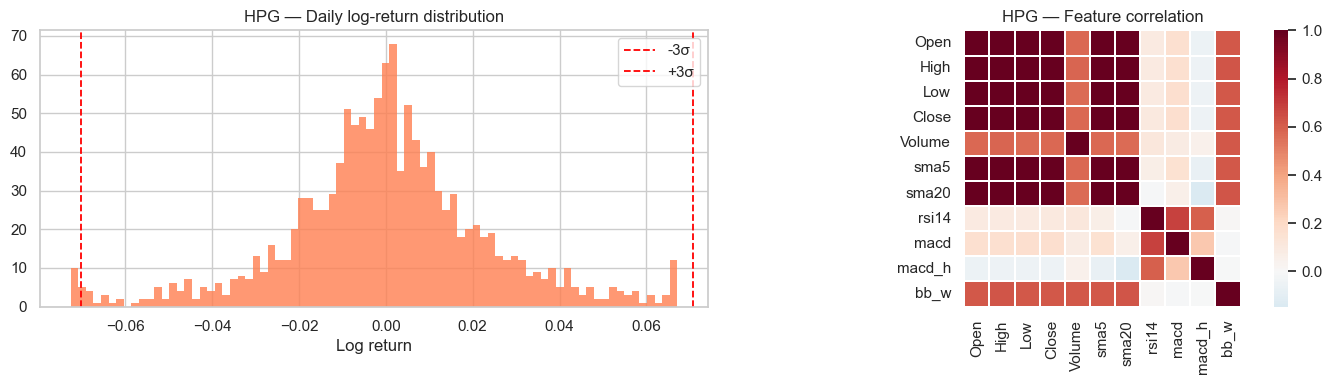

,Open,High,Low,Close,Volume,sma5,sma20,rsi14,macd,macd_h,bb_w
1282,21400.0,22100.0,21200.0,21200.0,32644751.0,21400.0,21072.5,49.218750,383.651262,-18.165139,2286.320878
1283,21150.0,21500.0,20400.0,21500.0,33600491.0,21440.0,21090.0,53.076923,387.621425,-11.355981,2317.530446
1284,21500.0,21500.0,20650.0,20800.0,14604476.0,21400.0,21055.0,47.552448,330.474157,-54.802599,2297.733437
1285,20400.0,20550.0,19950.0,20100.0,31325056.0,21040.0,20972.5,52.713178,226.094114,-127.346114,2350.789341
1286,20450.0,20500.0,19900.0,20000.0,15225174.0,20720.0,20867.5,42.201835,133.761098,-175.743303,2250.871176


In [29]:
TICKER_VN = 'HPG'
VN_FEATS  = ['Open', 'High', 'Low', 'Close', 'Volume',
             'sma5', 'sma20', 'rsi14', 'macd', 'macd_h', 'bb_w']

# ── EDA: clean + indicators ───────────────────────────────────────────────
vn_raw  = vn[vn['Ticker'] == TICKER_VN].sort_values('Date').copy()
n_before = len(vn_raw)
vn_raw  = clean_ohlcv(vn_raw)
vn_s    = add_indicators(vn_raw)
print(f'Rows: {n_before} raw  →  {len(vn_s)} after cleaning')

log_ret_vn = np.log(vn_s['Close'] / vn_s['Close'].shift(1)).dropna()
mu_vn, sd_vn = log_ret_vn.mean(), log_ret_vn.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(log_ret_vn, bins=80, color='coral', alpha=0.8, edgecolor='none')
for s, lbl in [(-3, '-3σ'), (3, '+3σ')]:
    axes[0].axvline(mu_vn + s * sd_vn, color='red', ls='--', lw=1.3, label=lbl)
axes[0].set_title(f'{TICKER_VN} — Daily log-return distribution')
axes[0].set_xlabel('Log return'); axes[0].legend()

corr_vn = vn_s[VN_FEATS].corr()
sns.heatmap(corr_vn, ax=axes[1], cmap='RdBu_r', center=0,
            linewidths=0.3, square=True)
axes[1].set_title(f'{TICKER_VN} — Feature correlation')

plt.tight_layout(); plt.show()
vn_s[VN_FEATS].tail()

### 2.1 Multi-feature Extension

In [ ]:
m21, sc21, yte21, ypred21, lc21, close21, ts21 = train_one(
    vn[vn['Ticker'] == TICKER_VN], VN_FEATS, epochs=30, verbose=1)
eval_regression(yte21, ypred21, '[Task 2.1]')
plot_pred(yte21, ypred21, f'Task 2.1 -- {TICKER_VN} next-day',
          close_arr=close21, t_start=ts21)


### 2.2 k-th Day Forecast

In [ ]:
for k in [3, 7]:
    close22, lr22, s22 = _prep_ticker(
        vn[vn['Ticker'] == TICKER_VN], VN_FEATS)
    X, y = make_seq_ahead(s22, lr22, WINDOW, d=k)
    Xtr, ytr, Xval, yval, Xte, yte_k = chrono_split(X, y)
    X1, _ = make_seq_ahead(s22, lr22, WINDOW, 1)
    Xtr1, _, Xval1, _, _, _ = chrono_split(X1, np.zeros(len(X1)))
    t_start22 = len(Xtr1) + len(Xval1) + WINDOW
    es  = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    rlr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                            patience=3, min_lr=1e-5)
    m   = build_lstm((WINDOW, len(VN_FEATS)), output_units=1)
    m.fit(Xtr, ytr, validation_data=(Xval, yval),
          epochs=30, batch_size=32, callbacks=[es, rlr], verbose=0)
    ypred_k = m.predict(Xte, verbose=0).flatten()
    eval_regression(yte_k, ypred_k, f'[Task 2.2 k={k}]')
    plot_pred(yte_k, ypred_k, f'Task 2.2 -- {TICKER_VN} {k}-th day',
              close_arr=close22, t_start=t_start22)


### 2.3 k Consecutive Days Forecast

In [ ]:
K = 7
close23, lr23, s23 = _prep_ticker(
    vn[vn['Ticker'] == TICKER_VN], VN_FEATS)

yte_days23, ypred_days23 = [], []
for d in range(1, K + 1):
    X, y = make_seq_ahead(s23, lr23, WINDOW, d)
    Xtr, ytr, Xval, yval, Xte, yte_d = chrono_split(X, y)
    es  = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    rlr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                            patience=3, min_lr=1e-5)
    md  = build_lstm((WINDOW, len(VN_FEATS)), output_units=1)
    md.fit(Xtr, ytr, validation_data=(Xval, yval),
           epochs=30, batch_size=32, callbacks=[es, rlr], verbose=0)
    yp_d = md.predict(Xte, verbose=0).flatten()
    yte_days23.append(yte_d)
    ypred_days23.append(yp_d)
    eval_regression(yte_d, yp_d, f'[Task 2.3 day+{d}]')

X1, _ = make_seq_ahead(s23, lr23, WINDOW, 1)
Xtr1, _, Xval1, _, _, _ = chrono_split(X1, np.zeros(len(X1)))
t_start23 = len(Xtr1) + len(Xval1) + WINDOW

lc23 = float(close23[t_start23 - 1])

act_p23 = [float(close23[t_start23 + d - 1]) for d in range(1, K + 1)]

pred_lr_cum23 = np.cumsum([float(ypred_days23[d][0]) for d in range(K)])
pred_p23 = [lc23 * float(np.exp(c)) for c in pred_lr_cum23]

plt.figure(figsize=(8, 4))
plt.plot(range(1, K + 1), act_p23,  'o-',  label='Actual')
plt.plot(range(1, K + 1), pred_p23, 's--', label='Predicted')
plt.xlabel('Day ahead'); plt.ylabel('Close price (VND)')
plt.title(f'Task 2.3 — {TICKER_VN} 7-day consecutive forecast (separate model per horizon)')
plt.legend(); plt.tight_layout(); plt.show()


### 2.4 Additional Vietnam Data (Dividend / Financial Ratio)

In [33]:
# Load dividend history
div_path = os.path.join(VN_DIV_DIR, f'{TICKER_VN}-VNINDEX-Dividend.csv')
if os.path.exists(div_path):
    div_df = pd.read_csv(div_path, parse_dates=['exerciseDate'])
    print('Dividend records:', len(div_df))
    display(div_df.head())

# Load financial ratio
fin_path = os.path.join(VN_FIN_DIR, f'{TICKER_VN}.csv')
if os.path.exists(fin_path):
    fin_df = pd.read_csv(fin_path)
    print('Financial ratio records:', len(fin_df))
    display(fin_df.head())

# TODO: merge dividend yield / P/E as additional features
# Approach: forward-fill quarterly financial data to daily frequency,
# then append as extra columns to VN_FEATS before training.

Dividend records: 20


,Unnamed: 0,exerciseDate,cashYear,cashDividendPercentage,issueMethod
0,0,2022-06-17,2021,0.05,cash
1,1,2022-06-17,2022,0.30,share
2,2,2021-05-31,2021,0.35,share
3,3,2021-05-31,2020,0.05,cash
4,4,2020-07-29,2019,0.05,cash


---
## Task 3 — Trading Signal Identification <a id='task3'></a>
> **20%** | Buy signal (3.1) · Sell signal (3.2)

### 3.0 Label Generation

Signal
0    946
2    184
1    157
Name: count, dtype: int64


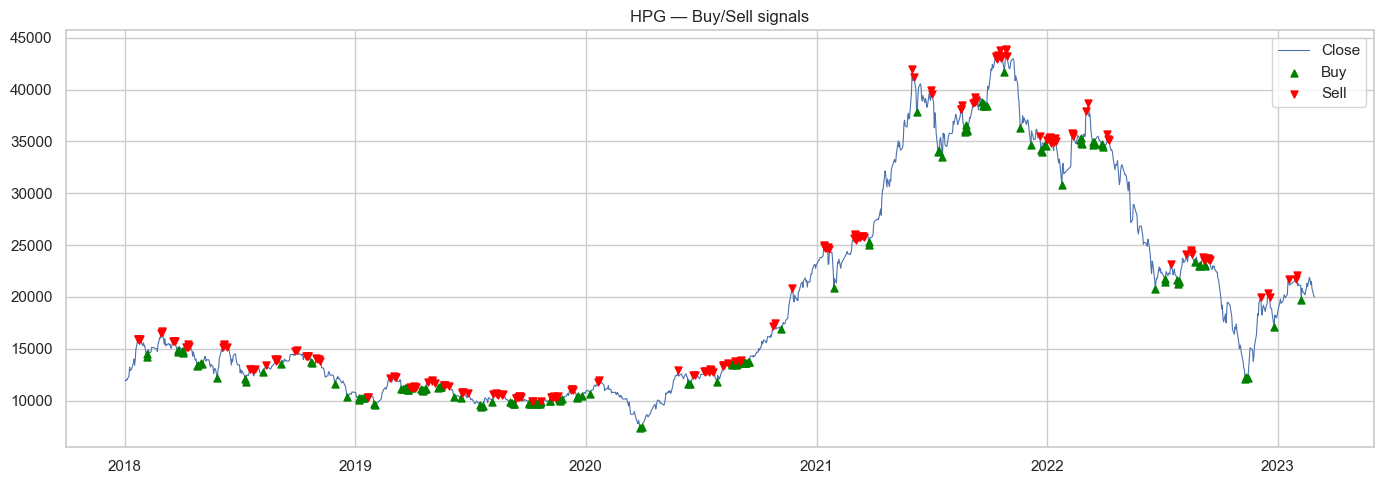

In [34]:
def generate_signals(prices, window=10, tol=0.02):
    """0=Hold  1=Buy  2=Sell
    Uses symmetric window (past+future) for labelling only.
    Model at inference uses only past data.
    """
    arr = prices.values if hasattr(prices,'values') else prices
    labels = np.zeros(len(arr), dtype=int)
    for i in range(window, len(arr)-window):
        local = arr[i-window: i+window+1]
        lo, hi = local.min(), local.max()
        if arr[i] <= lo*(1+tol):  labels[i] = 1  # Buy
        elif arr[i] >= hi*(1-tol): labels[i] = 2  # Sell
    return labels


vn_hpg = vn[vn['Ticker']==TICKER_VN].sort_values('Date').copy()
vn_hpg['Signal'] = generate_signals(vn_hpg['Close'], window=10)

print(vn_hpg['Signal'].value_counts())

# Visualise
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(vn_hpg['Date'], vn_hpg['Close'], lw=0.8, label='Close')
buys  = vn_hpg[vn_hpg['Signal']==1]
sells = vn_hpg[vn_hpg['Signal']==2]
ax.scatter(buys['Date'],  buys['Close'],  marker='^', color='green', s=25, label='Buy',  zorder=5)
ax.scatter(sells['Date'], sells['Close'], marker='v', color='red',   s=25, label='Sell', zorder=5)
ax.set_title(f'{TICKER_VN} — Buy/Sell signals'); ax.legend()
plt.tight_layout(); plt.show()

### 3.1 Technical Indicator Features

In [35]:
# add_indicators() is defined in the shared utilities cell above.
# Apply it to the HPG signal dataset and define signal feature list.
vn_hpg = add_indicators(vn_hpg)

SIG_FEATS = ['Open', 'High', 'Low', 'Close', 'Volume',
             'sma5', 'sma20', 'rsi14', 'macd', 'macd_s', 'macd_h',
             'bb_u', 'bb_l', 'bb_w']
print('Signal model features:', SIG_FEATS)

Signal model features: ['Open', 'High', 'Low', 'Close', 'Volume', 'sma5', 'sma20', 'rsi14', 'macd', 'macd_s', 'macd_h', 'bb_u', 'bb_l', 'bb_w']


### 3.2 Train Buy/Sell Classification Model

In [37]:
sc_sig = MinMaxScaler()
X_sig  = sc_sig.fit_transform(vn_hpg[SIG_FEATS])
y_sig  = vn_hpg['Signal'].values

Xs, ys = [], []
for i in range(WINDOW, len(X_sig)):
    Xs.append(X_sig[i-WINDOW:i])
    ys.append(y_sig[i])
Xs, ys = np.array(Xs), np.array(ys)

n  = len(Xs)
t1, t2 = int(n*0.70), int(n*0.85)
Xtr,ytr = Xs[:t1], ys[:t1]
Xval,yval = Xs[t1:t2], ys[t1:t2]
Xte,yte = Xs[t2:], ys[t2:]

# Handle class imbalance
cw = compute_class_weight('balanced', classes=np.unique(ytr), y=ytr)
class_w = dict(enumerate(cw))

m_sig = build_lstm((WINDOW, len(SIG_FEATS)), output_units=3, classify=True)
cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
m_sig.fit(Xtr, ytr, validation_data=(Xval,yval),
          epochs=50, batch_size=32, class_weight=class_w,
          callbacks=[cb], verbose=1)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.3329 - loss: 1.1144 - val_accuracy: 0.6995 - val_loss: 1.0007
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4136 - loss: 1.0665 - val_accuracy: 0.6995 - val_loss: 0.9805
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4685 - loss: 1.0352 - val_accuracy: 0.6995 - val_loss: 0.9648
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4591 - loss: 1.0008 - val_accuracy: 0.6995 - val_loss: 0.9617
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4720 - loss: 0.9722 - val_accuracy: 0.6995 - val_loss: 0.9565
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4883 - loss: 0.9629 - val_accuracy: 0.6995 - val_loss: 0.9566
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5140 - loss: 0.9396 - val_accuracy: 0.6995 - val_loss: 0.9663
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5129 - loss: 0.9225 - val_accuracy: 0.6995 - v

              precision    recall  f1-score   support

        Hold       0.80      0.92      0.86       148
         Buy       0.25      0.06      0.09        18
        Sell       0.10      0.06      0.07        18

    accuracy                           0.75       184
   macro avg       0.38      0.34      0.34       184
weighted avg       0.68      0.75      0.70       184



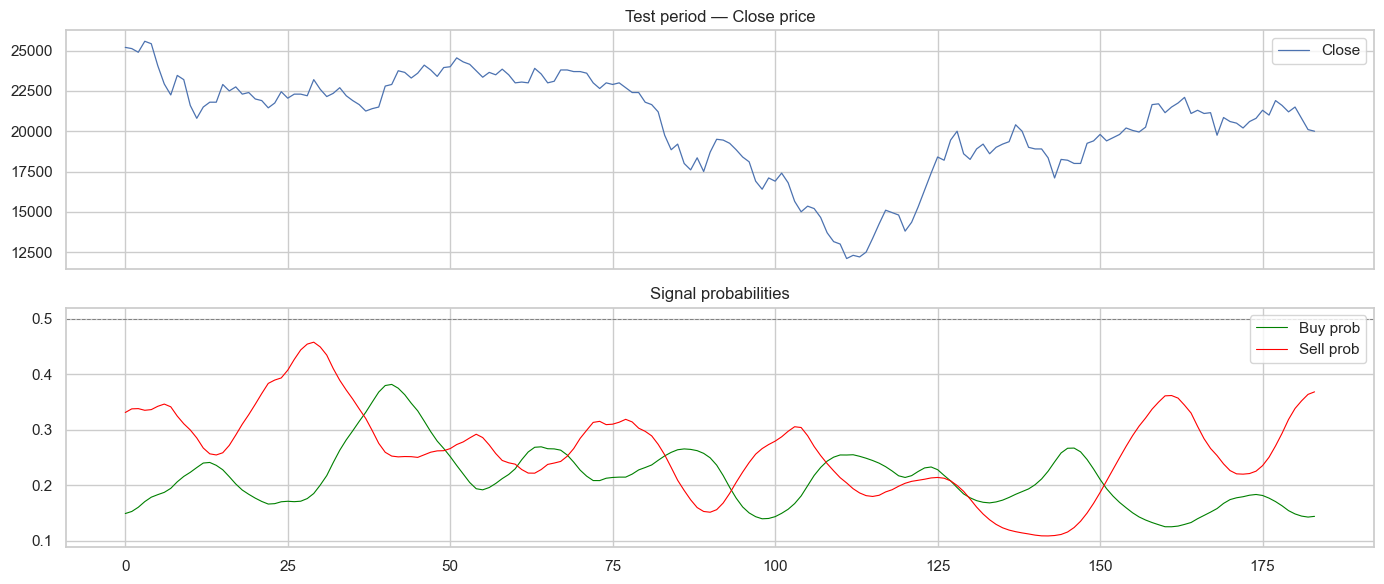

In [38]:
yp_sig = np.argmax(m_sig.predict(Xte, verbose=0), axis=1)
print(classification_report(yte, yp_sig, target_names=['Hold','Buy','Sell']))

# Plot signal probabilities on test period
probs = m_sig.predict(Xte, verbose=0)
fig, axes = plt.subplots(2,1,figsize=(14,6),sharex=True)
axes[0].plot(vn_hpg['Close'].values[-len(yte):], lw=0.9, label='Close')
axes[0].set_title('Test period — Close price'); axes[0].legend()
axes[1].plot(probs[:,1], lw=0.8, color='green', label='Buy prob')
axes[1].plot(probs[:,2], lw=0.8, color='red',   label='Sell prob')
axes[1].axhline(0.5, ls='--', color='gray', lw=0.7)
axes[1].set_title('Signal probabilities'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## Task 4 — Portfolio Optimization & Risk Management <a id='task4'></a>
> **30%** | Profitable selection (4.1) · Risk management (4.2) · Portfolio composition (4.3)

### 4.1 Profitable Stock Selection

In [ ]:
def profit_score(df_co, features, horizon=1):
    try:
        _, _, yte, ypred, _, _, _ = train_one(df_co, features, horizon=horizon, epochs=20)
        return float(np.mean(ypred.flatten()))
    except:
        return np.nan

tickers_vn = vn['Ticker'].unique()
profit = {}
for tk in tickers_vn[:20]:
    profit[tk] = profit_score(vn[vn['Ticker'] == tk], VN_FEATS)
    print(f'{tk}: {profit[tk]:.4f}')

profit_df = (pd.Series(profit).dropna()
               .sort_values(ascending=False)
               .to_frame('profit_score'))
profit_df.head(10).plot(kind='bar', figsize=(10, 4),
                        title='Top 10 — Predicted profitability')
plt.tight_layout(); plt.show()


### 4.2 Risk Management

        volatility    sharpe  max_drawdown  risk_score
Ticker                                                
ACG       0.294094 -1.171908     -0.539310    2.005313
AAT       0.473053 -0.591855     -0.769723    1.834631
ACM       1.383957  0.555432     -0.875000    1.703525
AAV       0.597091 -0.056366     -0.909721    1.563178
ABS       0.603657  0.030558     -0.926364    1.499463
AAS       0.709533  0.048840     -0.825000    1.485693
AAA       0.411205 -0.166448     -0.750439    1.328091
ABR       0.856031  0.439075     -0.793583    1.210538
ABC       0.521224  0.257320     -0.779412    1.043316
ACV       0.283810 -0.065036     -0.635972    0.984818
ABB       0.418182  0.126155     -0.657459    0.949486
ACS       0.708469  0.461405     -0.692737    0.939802
A32       0.653038  0.599382     -0.598997    0.652654
AAM       0.467087  0.454490     -0.481006    0.493603
ACL       0.492603  0.758851     -0.739367    0.473118
ABI       0.480330  0.499777     -0.491743    0.472296
ACE       

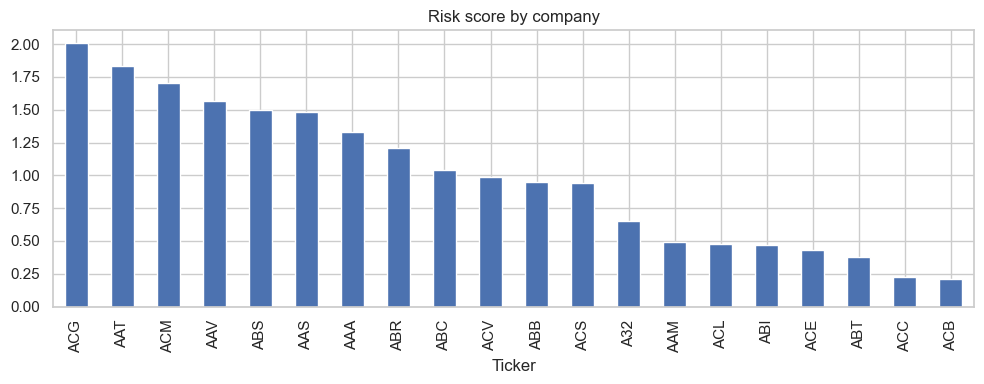

In [40]:
def risk_metrics(df_co):
    c = df_co.sort_values('Date')['Close']
    r = c.pct_change().dropna()
    vol = r.std() * np.sqrt(252)
    sharpe = r.mean() / r.std() * np.sqrt(252)
    cum  = (1+r).cumprod()
    mdd  = ((cum - cum.cummax())/cum.cummax()).min()
    risk = vol - sharpe + abs(mdd)  # composite risk score
    return {'volatility':vol,'sharpe':sharpe,'max_drawdown':mdd,'risk_score':risk}


risk_rows = []
for tk in tickers_vn[:20]:
    sub = vn[vn['Ticker']==tk]
    if len(sub) < MIN_DAYS: continue
    row = risk_metrics(sub); row['Ticker'] = tk
    risk_rows.append(row)

risk_df = pd.DataFrame(risk_rows).set_index('Ticker').sort_values('risk_score', ascending=False)
print(risk_df)
risk_df['risk_score'].plot(kind='bar', figsize=(10,4), title='Risk score by company')
plt.tight_layout(); plt.show()

### 4.3 Portfolio Composition (Mean-Variance Optimisation)

In [ ]:
combined = profit_df.join(risk_df, how='inner')
if len(combined) == 0:
    print('No combined candidates -- skipping portfolio optimisation.')
else:
    thresh_risk   = combined['risk_score'].median()
    thresh_profit = combined['profit_score'].median()
    cands = combined[(combined['profit_score'] >= thresh_profit) &
                     (combined['risk_score']    <  thresh_risk)]
    if len(cands) < 2:
        cands = combined.nlargest(max(2, len(combined) // 2), 'profit_score')
    print(f'Portfolio candidates: {len(cands)}'); print(cands)

    ret_matrix = {}
    for tk in cands.index:
        sub = vn[vn['Ticker'] == tk].sort_values('Date')
        ret_matrix[tk] = sub.set_index('Date')['Close'].pct_change()
    ret_df = pd.DataFrame(ret_matrix).dropna()

    if ret_df.empty or len(ret_df.columns) < 2:
        print('Not enough return data for optimisation.')
    else:
        mu  = ret_df.mean().values * 252
        cov = ret_df.cov().values  * 252
        n   = len(cands)
        def neg_sharpe(w):
            return -(w @ mu) / (np.sqrt(w @ cov @ w) + 1e-9)
        res = minimize(neg_sharpe, np.ones(n) / n,
                       bounds=[(0, 1)] * n,
                       constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1})
        weights = pd.Series(res.x, index=cands.index)
        print('\nOptimal weights:'); print(weights.sort_values(ascending=False))
        p_ret = weights.values @ mu
        p_vol = np.sqrt(weights.values @ cov @ weights.values)
        print(f'Expected return: {p_ret:.2%}  vol: {p_vol:.2%}  Sharpe: {p_ret/p_vol:.2f}')
        weights.sort_values().plot(kind='barh', figsize=(8, 5),
                                   title='Optimal portfolio allocation')
        plt.xlabel('Weight'); plt.tight_layout(); plt.show()


---
## Task 5 — Deployment <a id='task5'></a>
> **+30%** | REST API (5.1) · Streamlit SaaS (5.2) · AI workflow (5.3)

### 5.1 Save Models & Write FastAPI Server

In [ ]:
os.makedirs('saved_models', exist_ok=True)

# Save VN price model + its scaler (trained in Task 2.1)
m21.save('saved_models/vn_price_model.keras')
with open('saved_models/scaler_price.pkl', 'wb') as f:
    pickle.dump(sc21, f)

# Save signal classifier + its scaler (trained in Task 3)
m_sig.save('saved_models/vn_signal_model.keras')
with open('saved_models/scaler_signal.pkl', 'wb') as f:
    pickle.dump(sc_sig, f)

# Save constants needed at inference time
meta = {'WINDOW': WINDOW, 'VN_FEATS': VN_FEATS, 'VN_PRICE_DIR': VN_PRICE_DIR}
with open('saved_models/meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

print('Models and scalers saved to saved_models/')
print(f'  Price model input shape : (1, {WINDOW}, {len(VN_FEATS)})')


In [ ]:
fastapi_code = """
import os, pickle, numpy as np, pandas as pd
import tensorflow as tf
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List

app    = FastAPI(title="VN Stock Prediction API", version="1.0")
MODEL  = tf.keras.models.load_model("saved_models/vn_price_model.keras")
SCALER = pickle.load(open("saved_models/scaler_price.pkl", "rb"))
META   = pickle.load(open("saved_models/meta.pkl", "rb"))
WINDOW    = META["WINDOW"]
VN_FEATS  = META["VN_FEATS"]

def _add_indicators(df):
    c = df["Close"]
    df["sma5"]  = c.rolling(5).mean()
    df["sma20"] = c.rolling(20).mean()
    d    = c.diff()
    gain = d.clip(lower=0).rolling(14).mean()
    loss = (-d.clip(upper=0)).rolling(14).mean()
    df["rsi14"] = 100 - 100 / (1 + gain / loss)
    e12  = c.ewm(span=12, adjust=False).mean()
    e26  = c.ewm(span=26, adjust=False).mean()
    df["macd"]   = e12 - e26
    df["macd_s"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_h"] = df["macd"] - df["macd_s"]
    s20  = c.rolling(20).std()
    df["bb_u"] = df["sma20"] + 2*s20
    df["bb_l"] = df["sma20"] - 2*s20
    df["bb_w"] = df["bb_u"] - df["bb_l"]
    return df.dropna()

class OHLCVRequest(BaseModel):
    # rows: list of [Open, High, Low, Close, Volume] — need at least WINDOW+26 rows
    rows: List[List[float]]

@app.get("/health")
def health():
    return {"status": "ok", "window": WINDOW, "features": len(VN_FEATS)}

@app.post("/predict/price")
def predict_price(req: OHLCVRequest):
    if len(req.rows) < WINDOW + 26:
        raise HTTPException(400, f"Need >= {WINDOW + 26} rows, got {len(req.rows)}")
    df = pd.DataFrame(req.rows, columns=["Open", "High", "Low", "Close", "Volume"])
    df = _add_indicators(df)[VN_FEATS].dropna()
    if len(df) < WINDOW:
        raise HTTPException(400, "Not enough rows after indicator computation")
    window_data = df.values[-WINDOW:]
    scaled = SCALER.transform(window_data)[np.newaxis]   # (1, WINDOW, n_feats)
    pred_lr    = float(MODEL.predict(scaled, verbose=0)[0][0])
    last_close = float(df.iloc[-1]["Close"])
    pred_close = last_close * float(np.exp(pred_lr))
    return {
        "last_close":           round(last_close, 2),
        "predicted_log_return": round(pred_lr, 6),
        "predicted_next_close": round(pred_close, 2),
        "direction":            "UP" if pred_lr > 0 else "DOWN"
    }
"""

with open("main.py", "w") as f:
    f.write(fastapi_code)
print("main.py written.")
print("Run the API with:  uvicorn main:app --reload")
print("Then open:         http://127.0.0.1:8000/docs")


### 5.2 Streamlit Web App

In [ ]:
streamlit_code = """
import os, sys, pickle
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import tensorflow as tf

st.set_page_config(page_title="VN Stock Predictor", layout="wide")
st.title("Vietnam Stock Price Predictor")
st.caption("LSTM-based next-day close price prediction")

VN_PRICE_DIR = r"c:\\Users\\Administrator\\230163-DL4AI-project\\data-vn-20230228\\stock-historical-data"

def _add_indicators(df):
    df = df.copy()
    c = df["Close"]
    df["sma5"]  = c.rolling(5).mean()
    df["sma20"] = c.rolling(20).mean()
    d    = c.diff()
    gain = d.clip(lower=0).rolling(14).mean()
    loss = (-d.clip(upper=0)).rolling(14).mean()
    df["rsi14"] = 100 - 100 / (1 + gain / loss)
    e12  = c.ewm(span=12, adjust=False).mean()
    e26  = c.ewm(span=26, adjust=False).mean()
    df["macd"]   = e12 - e26
    df["macd_s"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_h"] = df["macd"] - df["macd_s"]
    s20  = c.rolling(20).std()
    df["bb_u"] = df["sma20"] + 2*s20
    df["bb_l"] = df["sma20"] - 2*s20
    df["bb_w"] = df["bb_u"] - df["bb_l"]
    return df.dropna()

@st.cache_resource
def load_artifacts():
    model  = tf.keras.models.load_model("saved_models/vn_price_model.keras")
    scaler = pickle.load(open("saved_models/scaler_price.pkl", "rb"))
    meta   = pickle.load(open("saved_models/meta.pkl", "rb"))
    return model, scaler, meta["WINDOW"], meta["VN_FEATS"]

@st.cache_data
def load_ticker(ticker):
    for suffix in ["VNINDEX", "HNXIndex", "UpcomIndex"]:
        path = os.path.join(VN_PRICE_DIR, f"{ticker}-{suffix}-History.csv")
        if os.path.exists(path):
            df = pd.read_csv(path, parse_dates=["TradingDate"])
            return df.rename(columns={"TradingDate": "Date"}).sort_values("Date")
    return None

# ── sidebar ──────────────────────────────────────────────────────────────
ticker = st.sidebar.selectbox("Ticker", ["HPG", "VNM", "FPT", "VCB", "MBB", "MSN", "VHM", "SSI"])
n_days = st.sidebar.slider("Chart history (days)", 60, 500, 200)

df_raw = load_ticker(ticker)
if df_raw is None:
    st.error(f"No CSV found for {ticker}")
    st.stop()

df = _add_indicators(df_raw)
recent = df.tail(n_days)

# ── price chart ───────────────────────────────────────────────────────────
fig = go.Figure()
fig.add_candlestick(x=recent["Date"], open=recent["Open"], high=recent["High"],
                    low=recent["Low"], close=recent["Close"], name="OHLC")
fig.add_scatter(x=recent["Date"], y=recent["sma20"], mode="lines",
                name="SMA20", line=dict(color="orange", dash="dash"))
fig.update_layout(title=f"{ticker} — last {n_days} trading days",
                  xaxis_title="Date", yaxis_title="Price (VND)",
                  xaxis_rangeslider_visible=False)
st.plotly_chart(fig, use_container_width=True)

# ── metrics row ───────────────────────────────────────────────────────────
last = df.iloc[-1]
col1, col2, col3, col4 = st.columns(4)
col1.metric("Last Close",  f"{last['Close']:,.0f}")
col2.metric("SMA20",       f"{last['sma20']:,.0f}")
col3.metric("RSI14",       f"{last['rsi14']:.1f}")
col4.metric("MACD",        f"{last['macd']:.2f}")

# ── prediction ────────────────────────────────────────────────────────────
st.divider()
if st.button("Predict next-day close price", type="primary"):
    try:
        model, scaler, WINDOW, VN_FEATS = load_artifacts()
        feat_data = df[VN_FEATS].dropna()
        if len(feat_data) < WINDOW:
            st.error(f"Need at least {WINDOW} rows, only have {len(feat_data)}")
        else:
            window_data = feat_data.values[-WINDOW:]
            scaled = scaler.transform(window_data)[np.newaxis]
            pred_lr    = float(model.predict(scaled, verbose=0)[0][0])
            last_close = float(feat_data.iloc[-1]["Close"])
            pred_close = last_close * np.exp(pred_lr)
            direction  = "UP" if pred_lr > 0 else "DOWN"
            color      = "normal" if pred_lr > 0 else "inverse"
            c1, c2, c3 = st.columns(3)
            c1.metric("Last Close",    f"{last_close:,.0f} VND")
            c2.metric("Predicted",     f"{pred_close:,.0f} VND",
                      f"{pred_lr*100:+.2f}%", delta_color=color)
            c3.metric("Direction",     direction)
    except FileNotFoundError:
        st.error("Models not found — run cell t51-save in the notebook first.")
    except Exception as e:
        st.error(f"Error: {e}")
"""

with open("streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)
print("streamlit_app.py written.")
print("Run with:  streamlit run streamlit_app.py")


### 5.3 AI Engineering Workflow

In [ ]:
workflow = """
AI Engineering Workflow
========================

1. INGESTION  (daily, via script or Airflow task)
   - Download OHLCV CSVs from exchange APIs / data vendors
   - Append to PostgreSQL table: raw.stock_prices

2. FEATURE ENGINEERING  (dbt or Python job)
   raw.stock_prices  ->  features.ohlcv          (cleaned)
                     ->  features.technical       (SMA, RSI, MACD, BB)
                     ->  features.fundamental     (P/E, dividend yield — quarterly)

3. TRAINING  (weekly or on-demand)
   - Retrain LSTM models on latest N days of data
   - Evaluate MAE / RMSE on held-out test window
   - Save model artefacts to saved_models/

4. INFERENCE  (daily, after market close)
   - Load latest WINDOW rows from features.technical
   - Call FastAPI /predict/price endpoint
   - Write predictions to predictions.daily_forecast

5. SERVING  (always-on)
   - FastAPI  : REST endpoint for programmatic access  (uvicorn main:app)
   - Streamlit: human-readable dashboard               (streamlit run streamlit_app.py)

6. MONITORING
   - Track prediction MAE vs realised prices each day
   - Alert if MAE rises > 2x historical baseline (model drift)
"""
print(workflow)
with open("workflow_description.txt", "w") as f:
    f.write(workflow)
print("Saved to workflow_description.txt")


---
## Summary & Conclusions

| Task | Description | Status |
|---|---|---|
| 1.1 | Nasdaq multi-feature | ✅ |
| 1.2 | Nasdaq k-th day forecast | ✅ |
| 1.3 | Nasdaq k consecutive days | ✅ |
| 2.1 | Vietnam multi-feature | ✅ |
| 2.2 | Vietnam k-th day forecast | ✅ |
| 2.3 | Vietnam k consecutive days | ✅ |
| 3.1 | Buy signal identification | ✅ |
| 3.2 | Sell signal identification | ✅ |
| 4.1 | Profitable stock selection | ✅ |
| 4.2 | Risk management | ✅ |
| 4.3 | Portfolio composition | ✅ |
| 5.1 | Model deployment (FastAPI) | ✅ |
| 5.2 | Model as SaaS (Streamlit) | ✅ |
| 5.3 | AI engineering workflow | ✅ |

### Key findings
*Fill in after running experiments — best window size, model accuracy per task, top portfolio stocks, achieved Sharpe ratio, F1-scores for buy/sell signals.*